# 09 - Image Feature Extraction from Histology

## Learning objectives
1. Extract a local H&E patch centered on each Visium spot, sized from the spot diameter.
2. Compute handcrafted features: RGB mean/std, H&E (stain) proxies, GLCM texture, local
   entropy, edge density, tissue fraction.
3. Store features per spot and visualize them spatially.
4. See `squidpy`'s built-in extractor as an alternative.

## Concept
This is **radiomics at microscopy scale**. For each spot we crop the image patch that the
spot physically covered and summarize its morphology with classic features - the same
intensity/texture/edge descriptors you would compute from a CT ROI. These become a
feature vector per spot, perfectly aligned with the expression matrix (same rows).


In [9]:
# --- Standard setup: make `utils` importable and seed RNGs ---
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'utils').exists():
    ROOT = ROOT.parent  # in case the notebook is opened from a subfolder
sys.path.insert(0, str(ROOT))

from utils import st_helpers as st
st.set_seeds()  # reproducibility (seed = 0)
print('Project root:', st.project_root())


Project root: /Users/justin/Documents/SpatialTranscriptomics-Tutorial


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata = st.load_adata('adata_clustered.h5ad')
sf = st.get_scalefactors(adata)
hires = st.get_image(adata, 'hires')

# uint8 RGB image and hires-space spot coordinates + patch size.
img = np.asarray(hires)
if img.dtype != np.uint8:
    img = (255 * np.clip(img, 0, 1)).astype(np.uint8)
img = img[..., :3]
scalef = sf['tissue_hires_scalef']
coords_hires = adata.obsm['spatial'] * scalef
patch = int(round(sf['spot_diameter_fullres'] * scalef))  # ~spot size in hires px
patch = max(patch, 8)
half = patch // 2
print('Image:', img.shape, '| patch size (hires px):', patch)


Image: (2000, 1921, 3) | patch size (hires px): 15


### Inspect per-spot image patches (before feature extraction)
Each Visium spot covers a ~55 µm circle on the tissue. Below we crop a square patch
centered on 12 example spots so you can see exactly what the 'radiomics' features will
summarize. Patch size is derived from `spot_diameter_fullres * tissue_hires_scalef`.

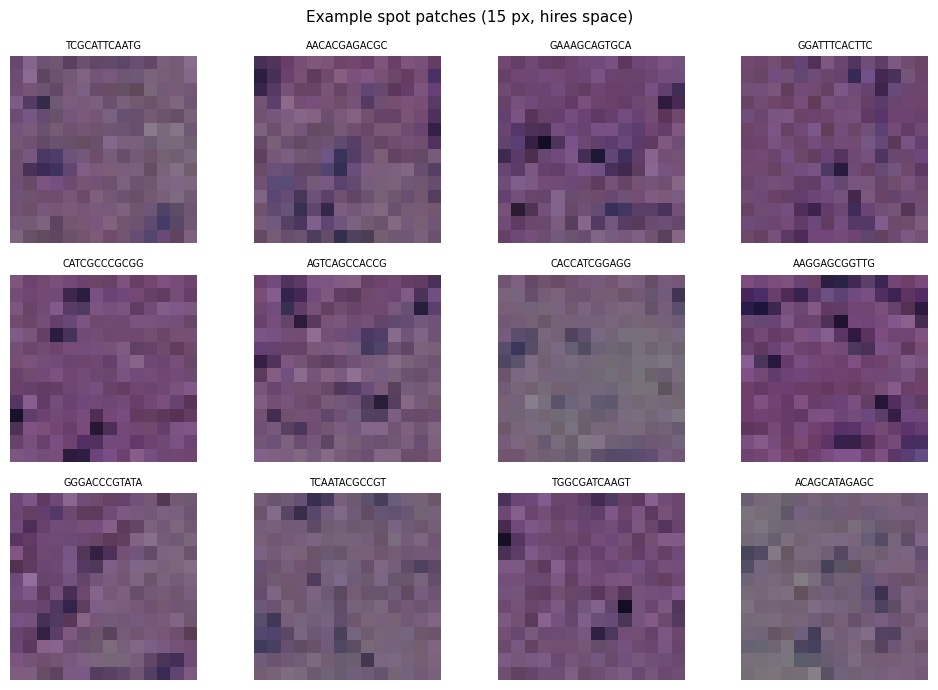

In [11]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(st.SEED)
n_show = 12
idx = rng.choice(adata.n_obs, size=min(n_show, adata.n_obs), replace=False)
fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for ax, i in zip(axes.ravel(), idx):
    x, y = coords_hires[i]
    xi, yi = int(round(x)), int(round(y))
    x0, x1 = max(0, xi - half), min(img.shape[1], xi + half)
    y0, y1 = max(0, yi - half), min(img.shape[0], yi + half)
    patch_img = img[y0:y1, x0:x1]
    ax.imshow(patch_img)
    ax.set_title(adata.obs_names[i][:12], fontsize=7)
    ax.axis('off')
fig.suptitle(f'Example spot patches ({patch} px, hires space)', fontsize=11)
plt.tight_layout()
st.save_fig(fig, '09_spot_patch_montage.png')
plt.show()


<details>
<summary><b>Your turn (exercise)</b></summary>

**Prompt:** Look at three patches. Can you guess whether each spot sits in white matter,
gray matter, or a mixed boundary from morphology alone?

**Expected answer:** White matter looks more homogeneous and pink (myelin-rich); gray matter
shows denser, darker nuclei (hematoxylin); boundaries look mixed. In notebook 10 we test
whether these visual cues predict gene expression.
</details>


### Per-spot patch feature function
We pull a square patch around each spot center and compute a fixed feature set. Spots whose
patch would fall off the image are clipped to the border.

In [12]:
from skimage.color import rgb2hed, rgb2gray
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import sobel
from skimage.filters.rank import entropy as rank_entropy
from skimage.morphology import disk
from skimage.util import img_as_ubyte

def patch_features(p):
    """Compute handcrafted features for one RGB uint8 patch."""
    feats = {}
    # --- color intensity (mean/std per channel) ---
    for i, c in enumerate('rgb'):
        feats[f'mean_{c}'] = float(p[..., i].mean())
        feats[f'std_{c}'] = float(p[..., i].std())
    # --- H&E stain proxies (nuclei vs cytoplasm density) ---
    hed = rgb2hed(p / 255.0)
    feats['hematoxylin_mean'] = float(hed[..., 0].mean())  # nuclei
    feats['eosin_mean'] = float(hed[..., 1].mean())        # cytoplasm/ECM
    # --- grayscale + texture (GLCM Haralick) ---
    gray = img_as_ubyte(rgb2gray(p))
    glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/2],
                        levels=256, symmetric=True, normed=True)
    for prop in ['contrast', 'homogeneity', 'energy', 'correlation']:
        feats[f'glcm_{prop}'] = float(graycoprops(glcm, prop).mean())
    # --- local entropy (texture randomness) ---
    feats['entropy_mean'] = float(rank_entropy(gray, disk(3)).mean())
    # --- edge density (Sobel magnitude) ---
    feats['edge_density'] = float(sobel(rgb2gray(p)).mean())
    # --- tissue fraction (non-background pixels in the patch) ---
    feats['tissue_fraction'] = float((gray < 220).mean())
    return feats


In [13]:
from tqdm import tqdm

H, W = img.shape[:2]
rows = []
for (x, y) in tqdm(coords_hires, desc='spots'):
    xi, yi = int(round(x)), int(round(y))
    x0, x1 = max(0, xi - half), min(W, xi + half)
    y0, y1 = max(0, yi - half), min(H, yi + half)
    p = img[y0:y1, x0:x1]
    if p.shape[0] < 4 or p.shape[1] < 4:  # degenerate border patch
        rows.append({})
        continue
    rows.append(patch_features(p))

feat_df = pd.DataFrame(rows, index=adata.obs_names)
feat_df = feat_df.fillna(feat_df.mean(numeric_only=True))  # fill rare border gaps
print('feature matrix:', feat_df.shape)
feat_df.head()


spots: 100%|██████████| 2688/2688 [00:24<00:00, 108.41it/s]

feature matrix: (2688, 15)


,mean_r,std_r,mean_g,std_g,mean_b,std_b,hematoxylin_mean,eosin_mean,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,entropy_mean,edge_density,tissue_fraction
AAACAAGTATCTCCCA-1,106.852041,15.295176,78.030612,12.095246,112.418367,9.566548,0.078339,0.005828,116.802198,0.128344,0.066276,0.615750,3.916804,0.036150,1.0
AAACAATCTACTAGCA-1,110.051020,15.962247,61.637755,11.356307,108.943878,12.221256,0.071860,0.026194,204.409341,0.111739,0.062224,0.295124,3.946263,0.039436,1.0
AAACACCAATAACTGC-1,112.678571,14.469311,89.943878,12.446699,114.841837,10.316446,0.072470,0.001309,190.851648,0.118017,0.061551,0.362233,3.927076,0.036881,1.0
AAACAGAGCGACTCCT-1,114.836735,7.815727,82.408163,14.294167,112.826531,8.162915,0.067703,0.009235,65.313187,0.166493,0.066277,0.753604,3.764341,0.024994,1.0
AAACCGGGTAGGTACC-1,110.367347,14.135920,78.566327,12.075895,112.918367,10.247621,0.073735,0.007567,241.975275,0.082241,0.060747,0.157754,3.938982,0.032852,1.0


**Expected output:** a spots x ~15 feature DataFrame (mean/std RGB, hematoxylin/eosin
means, four GLCM texture stats, entropy, edge density, tissue fraction).

### Store features in AnnData and save CSV
We keep the feature matrix in `adata.obsm['img_features']` (aligned to spots) and also copy
a few headline features into `adata.obs` for easy plotting.

In [14]:
adata.obsm['img_features'] = feat_df.values
adata.uns['img_feature_names'] = list(feat_df.columns)
for col in ['hematoxylin_mean', 'eosin_mean', 'glcm_contrast',
            'entropy_mean', 'edge_density', 'tissue_fraction']:
    adata.obs[f'img_{col}'] = feat_df[col].values

feat_csv = st.outputs_dir() / 'image_features.csv'
feat_df.to_csv(feat_csv)
print('Wrote', feat_csv)


Wrote /Users/justin/Documents/SpatialTranscriptomics-Tutorial/outputs/image_features.csv


### Visualize image features over the tissue

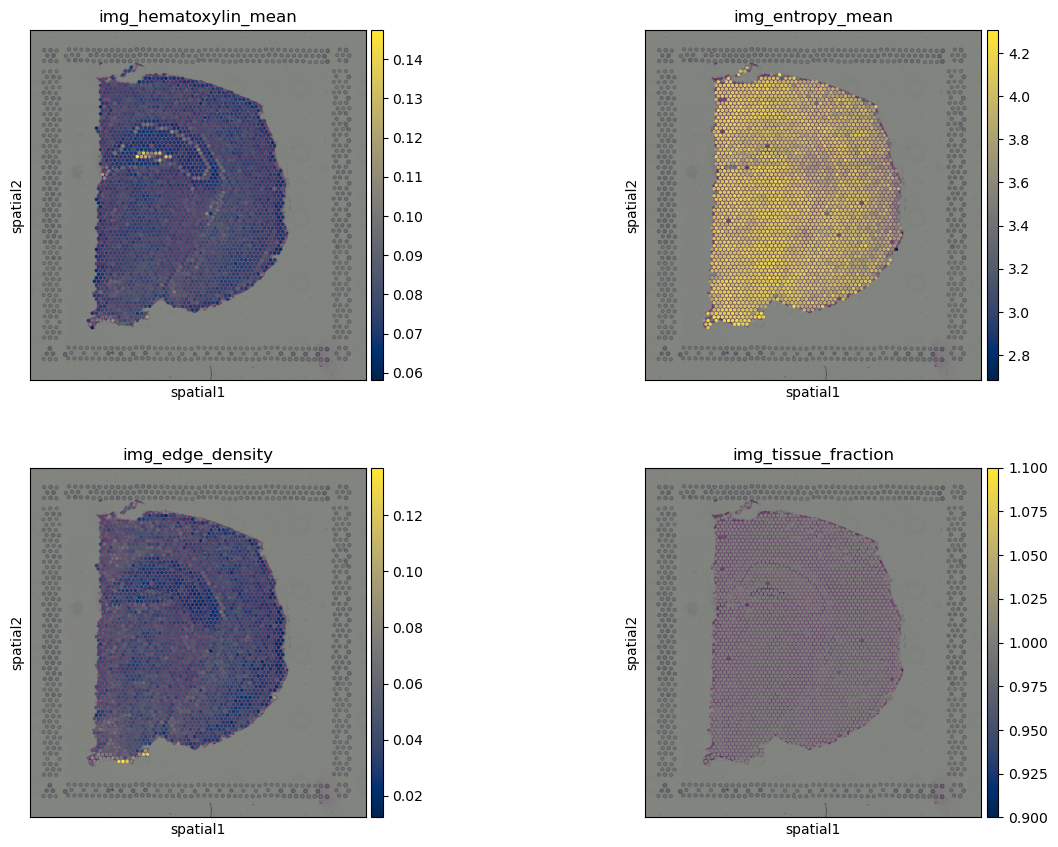

In [15]:
import squidpy as sq
sq.pl.spatial_scatter(
    adata,
    color=['img_hematoxylin_mean', 'img_entropy_mean',
           'img_edge_density', 'img_tissue_fraction'],
    ncols=2, size=1.3, cmap='cividis',
)


**Expected output:** feature maps that themselves show tissue structure - e.g. hematoxylin
(nuclear density) and texture features tracing anatomy, echoing the expression maps.

### Alternative: squidpy's `ImageContainer`
Squidpy can extract summary/texture/histogram features for you. It is convenient but the
handcrafted route above is transparent and gives us exactly the radiomics-style features
we want. The squidpy version (not run here to keep dependencies light) looks like:

```python
import squidpy as sq
lib = st.get_library_id(adata)
container = sq.im.ImageContainer(
    st.get_image(adata, 'hires'),
    scale=adata.uns['spatial'][lib]['scalefactors']['tissue_hires_scalef'],
)
sq.im.calculate_image_features(
    adata, container, features=['summary', 'texture', 'histogram'],
    key_added='squidpy_img_features',
)
```

### Note on CNN features
In a research setting you would often replace (or augment) handcrafted features with a CNN
embedding (e.g. a pathology foundation model) of each patch. The pipeline is identical -
swap `patch_features` for `model(patch)` - which is why we kept the patch-extraction loop
modular.


In [16]:
saved = st.save_adata(adata, 'adata_features.h5ad')
print('Wrote', saved)


Wrote /Users/justin/Documents/SpatialTranscriptomics-Tutorial/data/processed/adata_features.h5ad


## Common pitfalls
- Forgetting the scale factor when converting spot coords to hires pixels (patches land in
  the wrong place) - reuse `coords * tissue_hires_scalef`.
- Patch size from full-res pixels applied to the hires image - must scale it too.
- GLCM on an RGB or float image - convert to a uint8 grayscale first.

## Interpretation
Every spot now has both a gene-expression vector and an image-feature vector, perfectly
aligned. We are ready to relate morphology to molecules.

## What this means biologically
Handcrafted features quantify what a pathologist eyeballs: nuclear density, texture,
edges, cellularity. If these morphological summaries track expression, then routine H&E
carries recoverable molecular information.

---
**Next:** `10_integrating_histology_features_with_gene_expression.ipynb`.
